In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

In [ ]:
df = pd.read_csv("/content/insurance.csv")

In [ ]:
df.head(5)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [ ]:
df.isna().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [ ]:
df.duplicated().sum()

np.int64(1)

<Axes: >

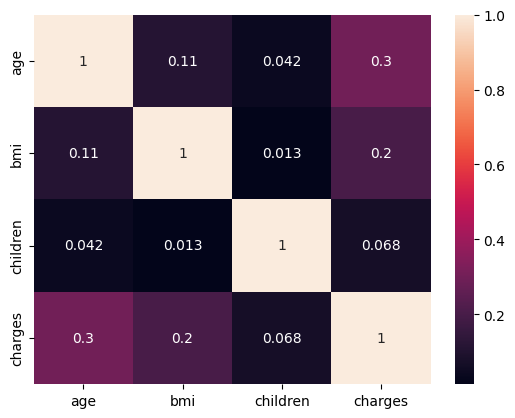

In [ ]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True)

<Axes: xlabel='smoker', ylabel='count'>

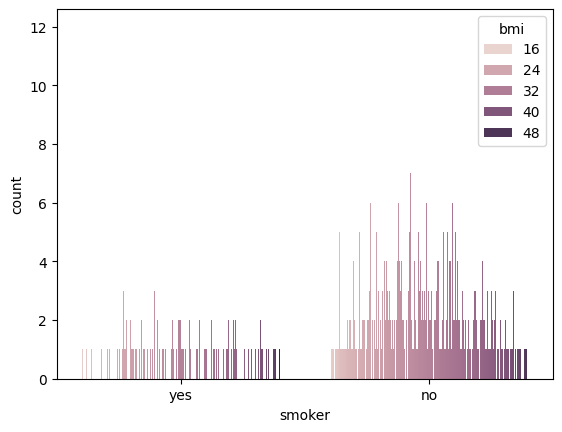

In [ ]:
sns.countplot(data=df,x="smoker",hue="bmi")

<Axes: xlabel='sex', ylabel='count'>

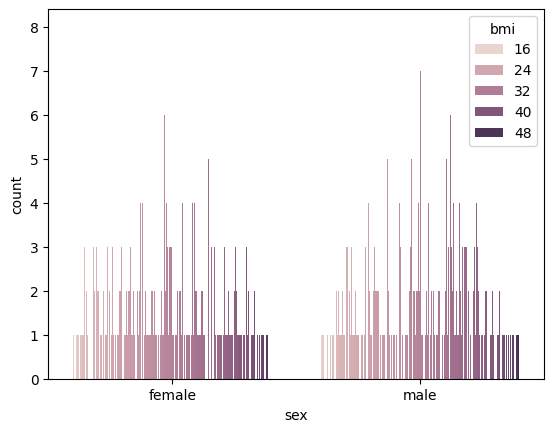

In [ ]:
sns.countplot(data=df,x="sex",hue="bmi")

Text(0.5, 1.0, 'Charges by Smoking Status')

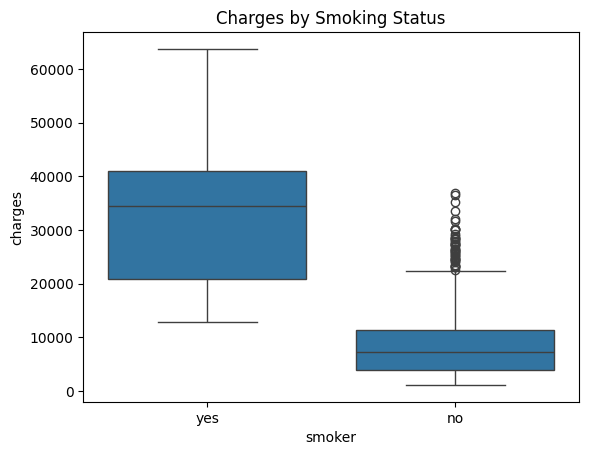

In [ ]:
sns.boxplot(x="smoker",y="charges",data=df)
plt.title("Charges by Smoking Status")

Text(0.5, 1.0, 'Smoker vs Non Smoker')

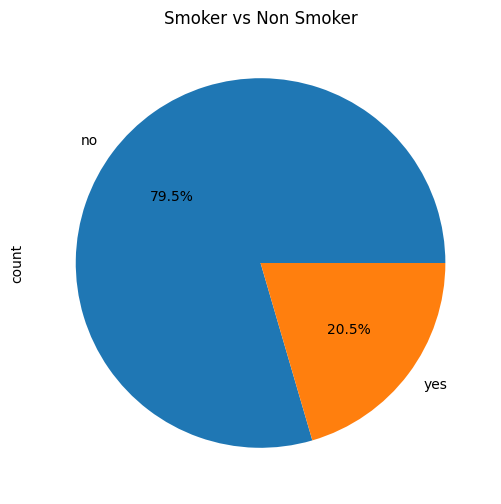

In [ ]:
plt.figure(figsize = (6,6))
df["smoker"].value_counts().plot.pie(autopct="%1.1f%%")
plt.title("Smoker vs Non Smoker")

<Axes: ylabel='count'>

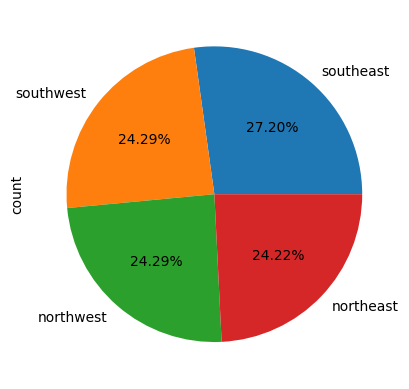

In [ ]:
df["region"].value_counts().plot.pie(autopct="%1.2f%%")

<Axes: xlabel='region', ylabel='charges'>

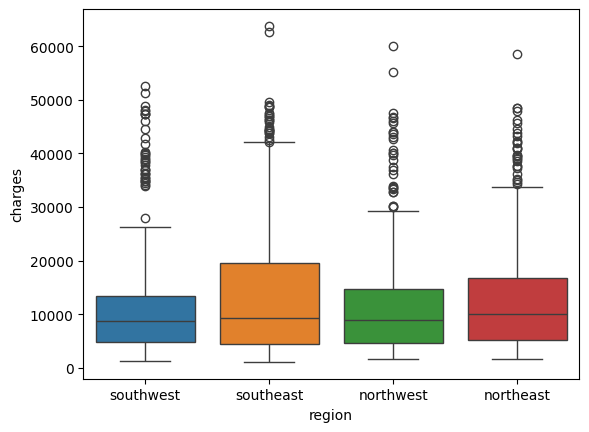

In [ ]:
sns.boxplot(data=df,x="region",y="charges",hue="region")

In [ ]:
df.groupby("region")["charges"].describe()

,count,mean,std,min,25%,50%,75%,max
region,,,,,,,,
northeast,324.0,13406.384516,11255.803066,1694.7964,5194.322288,10057.652025,16687.3641,58571.07448
northwest,325.0,12417.575374,11072.276928,1621.3402,4719.736550,8965.795750,14711.7438,60021.39897
southeast,364.0,14735.411438,13971.098589,1121.8739,4440.886200,9294.131950,19526.2869,63770.42801
southwest,325.0,12346.937377,11557.179101,1241.5650,4751.070000,8798.593000,13462.5200,52590.82939


<Axes: xlabel='region', ylabel='charges'>

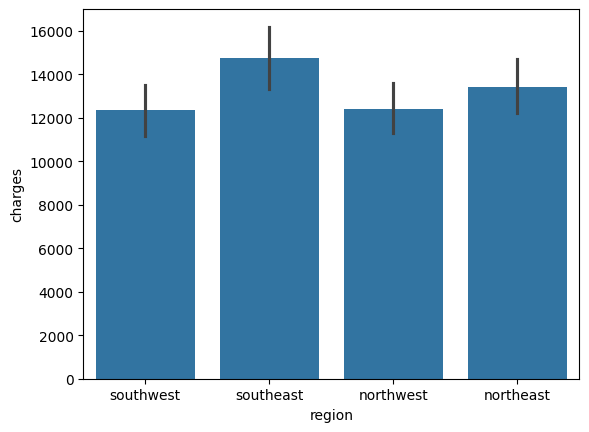

In [ ]:
sns.barplot(data=df, x="region",y="charges")

<Axes: xlabel='smoker', ylabel='charges'>

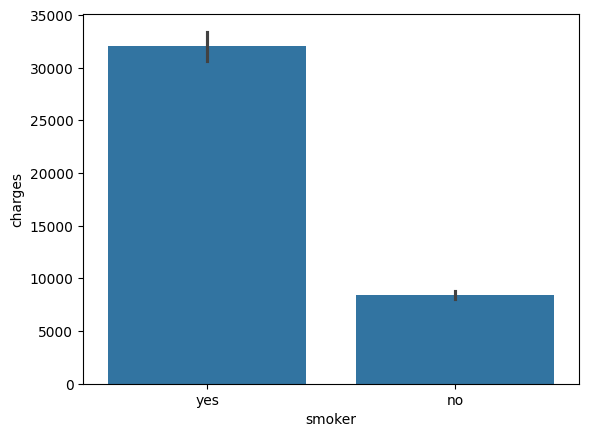

In [ ]:
sns.barplot(data=df,x="smoker",y="charges")

<Axes: xlabel='bmi', ylabel='Count'>

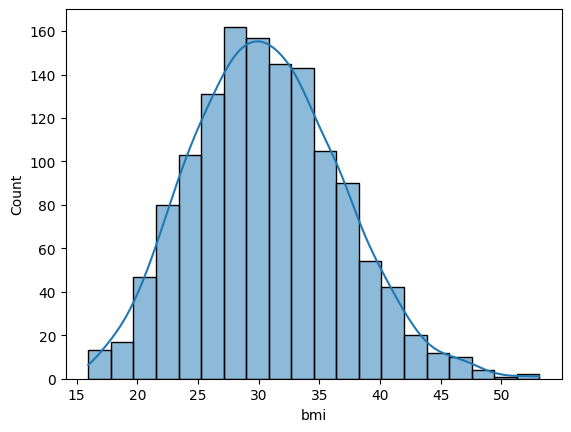

In [ ]:
sns.histplot(df["bmi"],bins = 20, kde = True)

In [ ]:
df.groupby("region").agg({
    'charges':"mean",
    'bmi':"median",
    'age': ["mean","median"]
})

charges    bmi        age       
                   mean median       mean median
region                                          
northeast  13406.384516  28.88  39.268519   39.5
northwest  12417.575374  28.88  39.196923   39.0
southeast  14735.411438  33.33  38.939560   39.0
southwest  12346.937377  30.30  39.455385   39.0

In [ ]:
def encoding(df):
  df = pd.get_dummies(
      df,
      columns = ["sex","smoker","region"],
      dtype = int
  )
  return df

In [ ]:
df = encoding(df)
df

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,1,0,0,1,0,0,0,1
1,18,33.770,1,1725.55230,0,1,1,0,0,0,1,0
2,28,33.000,3,4449.46200,0,1,1,0,0,0,1,0
3,33,22.705,0,21984.47061,0,1,1,0,0,1,0,0
4,32,28.880,0,3866.85520,0,1,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,30.970,3,10600.54830,0,1,1,0,0,1,0,0
1334,18,31.920,0,2205.98080,1,0,1,0,1,0,0,0
1335,18,36.850,0,1629.83350,1,0,1,0,0,0,1,0
1336,21,25.800,0,2007.94500,1,0,1,0,0,0,0,1


In [ ]:
X= df.drop(columns=["charges"])
y= df["charges"]

In [ ]:
##standardization
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)



In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train

array([[ 0.47222651, -1.75652513,  0.73433626, ...,  1.78316783,
        -0.59966106, -0.5723141 ],
       [ 0.54331294, -1.03308239, -0.91119211, ..., -0.56079971,
        -0.59966106, -0.5723141 ],
       [ 0.8987451 , -0.94368672, -0.91119211, ..., -0.56079971,
         1.66760869, -0.5723141 ],
       ...,
       [ 1.3252637 , -0.89153925, -0.91119211, ..., -0.56079971,
        -0.59966106, -0.5723141 ],
       [-0.16755139,  2.82086429,  0.73433626, ..., -0.56079971,
        -0.59966106,  1.74729228],
       [ 1.1120044 , -0.10932713, -0.91119211, ..., -0.56079971,
        -0.59966106,  1.74729228]])

In [ ]:
model = LinearRegression().fit(X_train,y_train)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.neighbors import KNeighborsRegressor

In [ ]:
mean_squared_error(y_test, y_pred)

33596915.85136148

In [ ]:
root_mean_squared_error(y_test, y_pred)

5796.284659276275

In [ ]:
mean_absolute_error(y_test, y_pred)

4181.194473753653

In [ ]:
knr = KNeighborsRegressor()
knr.fit(X_train,y_train)

KNeighborsRegressor()

In [ ]:
y_pred2 = knr.predict(X_test)

In [ ]:
mean_squared_error(y_test, y_pred2)

31174145.013288442

In [ ]:
root_mean_squared_error(y_test, y_pred2)

5583.381145263902

In [ ]:
mean_absolute_error(y_test, y_pred2)

3540.8607413022387